# Cell 1: Imports & Setup


In [10]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn modules for preprocessing, modeling, and tuning
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Statsmodels for Time Series Forecasting
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="whitegrid")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Cell 2: Data Loading & Preprocessing
**Action: Handling date formats, sorting chronologically, and checking for missing values.**

In [11]:
import kagglehub
import pandas as pd
import os

# 1. Download latest version
path = kagglehub.dataset_download("nalisha/tesla-ea-deliveries-and-production-data20152025")
print("Path to dataset files:", path)

# 2. Dynamically construct the file path
csv_file_path = os.path.join(path, 'tesla_deliveries_dataset_2015_2025.csv')

# 3. Load the dataset
df = pd.read_csv(csv_file_path)

# 4. Create Date column
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))

# 5. Sort chronologically (Crucial for time series!)
df = df.sort_values('Date').reset_index(drop=True)

# 6. Dataset info
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# 7. First rows
df.head()

Path to dataset files: /kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Year                  2640 non-null   int64         
 1   Month                 2640 non-null   int64         
 2   Region                2640 non-null   object        
 3   Model                 2640 non-null   object        
 4   Estimated_Deliveries  2640 non-null   int64         
 5   Production_Units      2640 non-null   int64         
 6   Avg_Price_USD         2640 non-null   float64       
 7   Battery_Capacity_kWh  2640 non-null   int64         
 8   Range_km              2640 non-null   int64         
 9   CO2_Saved_tons        2640 non-null   float64       
 10  Source_Type           2640 non-null   object        
 11  Charging_Stations 

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


# Cell 3: Exploratory Data Analysis (EDA)
**Action: Visualizing sales trends over time, price distributions, and feature correlations.**

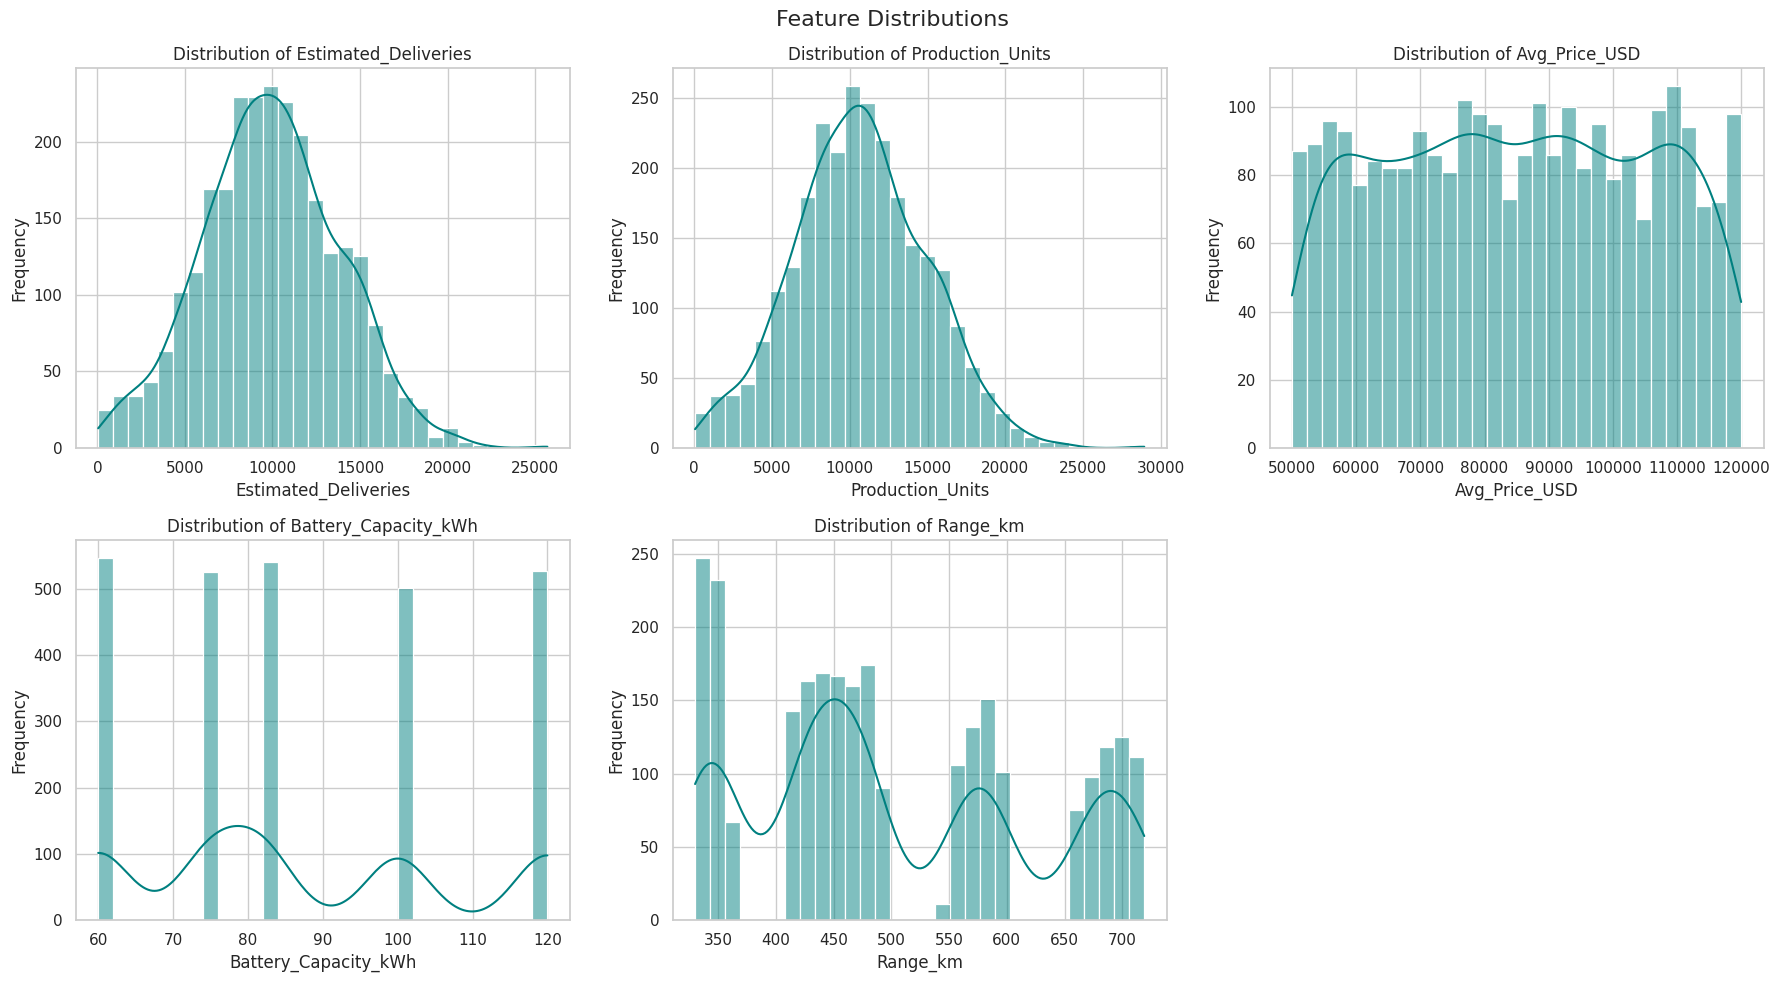

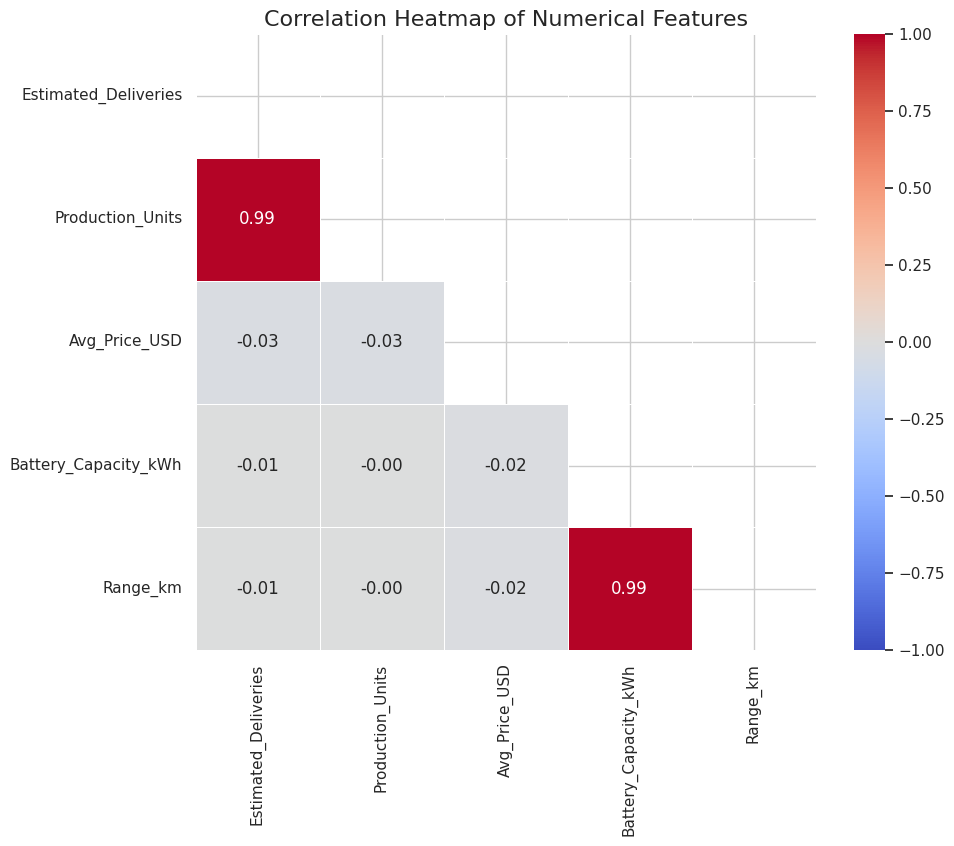

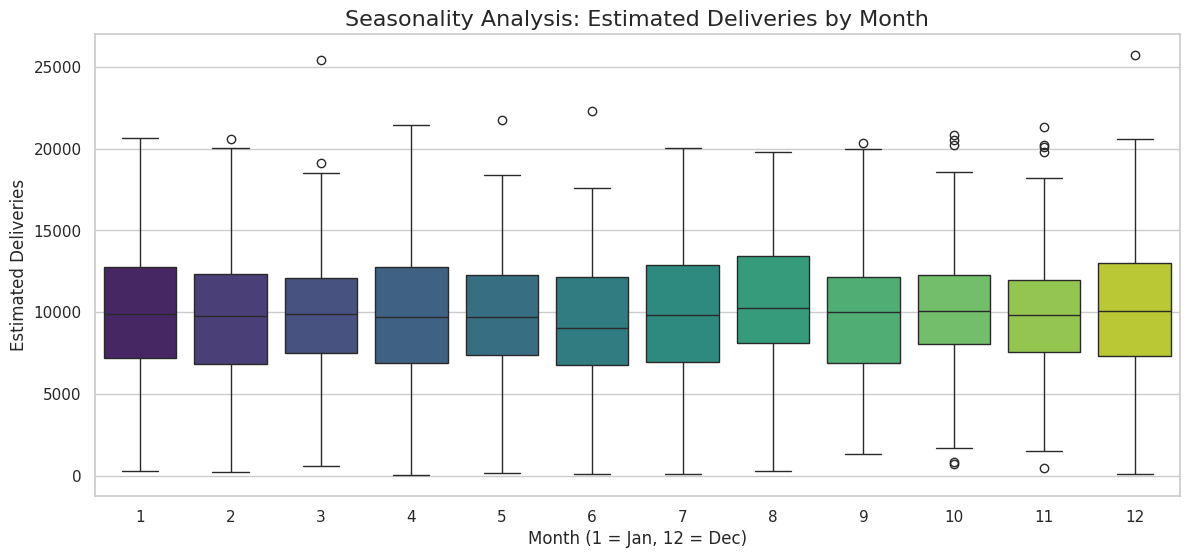

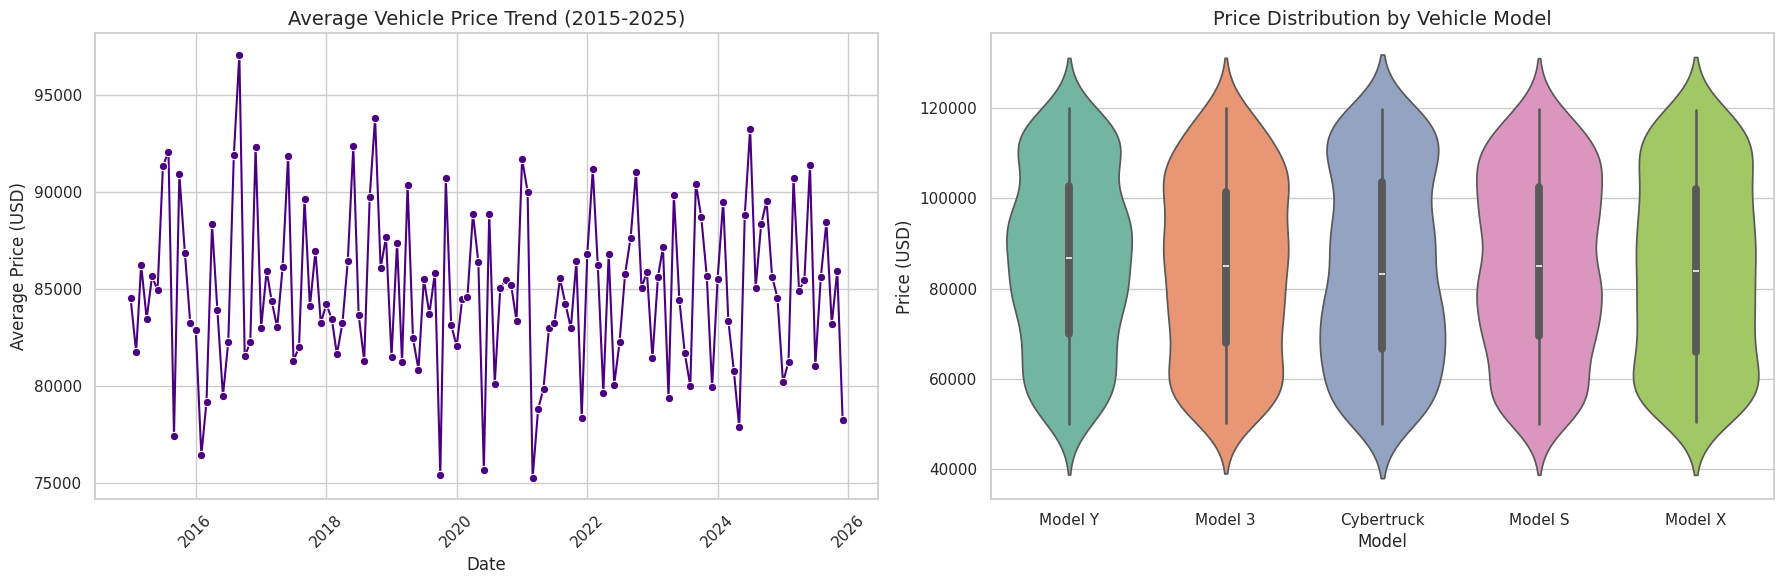

In [12]:


# Set up the visual style
sns.set_theme(style="whitegrid")

# Define key numerical columns for analysis
numeric_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km']

# 1. Feature Distributions (Histograms with KDE)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Feature Distributions', fontsize=16)
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel('Frequency')

# Remove the empty 6th subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
# Calculate correlation matrix for numerical features
corr_matrix = df[numeric_cols].corr()

# Create a mask for the upper triangle to make it cleaner
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

# 3. Seasonality / Monthly Pattern Analysis
plt.figure(figsize=(14, 6))
# Using a boxplot to see the variance and median deliveries per month across all years
sns.boxplot(data=df, x='Month', y='Estimated_Deliveries', palette='viridis')
plt.title('Seasonality Analysis: Estimated Deliveries by Month', fontsize=16)
plt.xlabel('Month (1 = Jan, 12 = Dec)')
plt.ylabel('Estimated Deliveries')
plt.show()

# 4. Price Trend & Distribution Analysis
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Price Trend Over Time
monthly_price = df.groupby('Date')['Avg_Price_USD'].mean().reset_index()
sns.lineplot(data=monthly_price, x='Date', y='Avg_Price_USD', ax=axes[0], color='indigo', marker='o')
axes[0].set_title('Average Vehicle Price Trend (2015-2025)', fontsize=14)
axes[0].set_ylabel('Average Price (USD)')
axes[0].tick_params(axis='x', rotation=45)

# Price Distribution by Vehicle Model
sns.violinplot(data=df, x='Model', y='Avg_Price_USD', ax=axes[1], palette='Set2')
axes[1].set_title('Price Distribution by Vehicle Model', fontsize=14)
axes[1].set_ylabel('Price (USD)')

plt.tight_layout()
plt.show()

# Cell 4: Feature Engineering
**Action: Creating new temporal and derived features to improve regression model performance.**

In [13]:
# ════════════════════════════════════════════════════════
#  CELL 4 : FEATURE ENGINEERING 
# ════════════════════════════════════════════════════════
import numpy as np
from sklearn.preprocessing import LabelEncoder # <-- ADDED IMPORT

df_fe = df.copy()

# ── 1. Temporal Features ──────────────────────────────────
df_fe['Quarter']          = df_fe['Date'].dt.quarter
df_fe['Is_Q4']            = (df_fe['Quarter'] == 4).astype(int)
df_fe['Is_Year_End']      = (df_fe['Month'] == 12).astype(int)
df_fe['Days_Since_Start'] = (df_fe['Date'] - df_fe['Date'].min()).dt.days

# ── 2. Cyclical Encoding for Month ───────────────────────
df_fe['Month_Sin'] = np.sin(2 * np.pi * df_fe['Month'] / 12)
df_fe['Month_Cos'] = np.cos(2 * np.pi * df_fe['Month'] / 12)

# ── 3. Price & Value Features ────────────────────────────
df_fe['Price_per_Range_km'] = df_fe['Avg_Price_USD'] / df_fe['Range_km']
df_fe['Price_per_kWh']      = df_fe['Avg_Price_USD'] / df_fe['Battery_Capacity_kWh']
median_price                = df_fe['Avg_Price_USD'].median()
df_fe['Is_Premium']         = (df_fe['Avg_Price_USD'] > median_price).astype(int)

# ── 4. Production Efficiency Features ────────────────────
df_fe['Delivery_Rate']   = (df_fe['Estimated_Deliveries'] /
                             df_fe['Production_Units'].replace(0, np.nan))
df_fe['Production_Gap']  = (df_fe['Production_Units'] -
                             df_fe['Estimated_Deliveries'])

# ── 5. Lag Features (global monthly totals) ───────────────
df_fe.sort_values('Date', inplace=True)
df_fe.reset_index(drop=True, inplace=True)

# FIX: Compute lags on the grouped dataframe FIRST, then merge
global_monthly = (df_fe.groupby('Date')['Estimated_Deliveries']
                  .sum()
                  .rename('Global_Total')
                  .reset_index())
global_monthly.sort_values('Date', inplace=True)

for lag in [1, 3, 6, 12]:
    global_monthly[f'Global_Lag_{lag}'] = global_monthly['Global_Total'].shift(lag)

# Merge the pre-calculated lags back into the main dataframe
df_fe = df_fe.merge(global_monthly.drop(columns=['Global_Total']), on='Date', how='left')

# ── 6. Rolling Statistics ─────────────────────────────────
# FIX: Group by Region and Model so rolling stats don't bleed across different vehicle types
df_fe['Roll3_Mean']  = df_fe.groupby(['Region', 'Model'])['Estimated_Deliveries'].transform(lambda x: x.rolling(3).mean())
df_fe['Roll6_Std']   = df_fe.groupby(['Region', 'Model'])['Estimated_Deliveries'].transform(lambda x: x.rolling(6).std())
df_fe['Roll12_Mean'] = df_fe.groupby(['Region', 'Model'])['Estimated_Deliveries'].transform(lambda x: x.rolling(12).mean())

# ── 7. Encode Categoricals ────────────────────────────────
le_region = LabelEncoder()
le_model  = LabelEncoder()
df_fe['Region_Enc'] = le_region.fit_transform(df_fe['Region'])
df_fe['Model_Enc']  = le_model.fit_transform(df_fe['Model'])

# ── 8. Drop NaN rows created by lag/rolling ───────────────
df_fe.dropna(inplace=True)
df_fe.reset_index(drop=True, inplace=True)

# ── 9. Define Features & Target ───────────────────────────
target = 'Estimated_Deliveries'

model_features = [
    # Temporal
    'Year', 'Month', 'Quarter', 'Is_Q4', 'Is_Year_End',
    'Month_Sin', 'Month_Cos', 'Days_Since_Start',
    # Product & Price
    'Region_Enc', 'Model_Enc',
    'Avg_Price_USD', 'Battery_Capacity_kWh',
    'Range_km', 'Charging_Stations',
    'Price_per_Range_km', 'Price_per_kWh', 'Is_Premium',
    # Production
    'Production_Gap', 'Delivery_Rate',
    # Lag & Rolling
    'Global_Lag_1', 'Global_Lag_3',
    'Global_Lag_6', 'Global_Lag_12',
    'Roll3_Mean', 'Roll6_Std', 'Roll12_Mean',
]

X = df_fe[model_features]
y = df_fe[target]

# ── 10. Summary ───────────────────────────────────────────
print(f"✅ Feature engineering complete!")
print(f"   Total features  : {len(model_features)}")
print(f"   Dataset shape   : {df_fe.shape}")
print(f"\nFeature list:")
for i, f in enumerate(model_features, 1):
    print(f"   {i:>2}. {f}")

✅ Feature engineering complete!
   Total features  : 26
   Dataset shape   : (2400, 33)

Feature list:
    1. Year
    2. Month
    3. Quarter
    4. Is_Q4
    5. Is_Year_End
    6. Month_Sin
    7. Month_Cos
    8. Days_Since_Start
    9. Region_Enc
   10. Model_Enc
   11. Avg_Price_USD
   12. Battery_Capacity_kWh
   13. Range_km
   14. Charging_Stations
   15. Price_per_Range_km
   16. Price_per_kWh
   17. Is_Premium
   18. Production_Gap
   19. Delivery_Rate
   20. Global_Lag_1
   21. Global_Lag_3
   22. Global_Lag_6
   23. Global_Lag_12
   24. Roll3_Mean
   25. Roll6_Std
   26. Roll12_Mean


# Cell 5: Regression Model & Hyper Tuning

Train size : 1,920 rows
Test  size : 480 rows
Features   : 26

✅ Linear Regression trained
   R²      : 0.7618
   CV R²   : 0.7903
   RMSE    : 1,818.75
   MAPE    : 21.13%

--- Tuning Lasso with GridSearchCV ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.267e+08, tolerance: 5.373e+05
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.018e+09, tolerance: 1.108e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.529e+09, tolerance: 1.557e

Best Alpha  : 50
CV R²       : 0.7879
Test R²     : 0.7607
RMSE        : 1,823.08
MAPE        : 20.87%


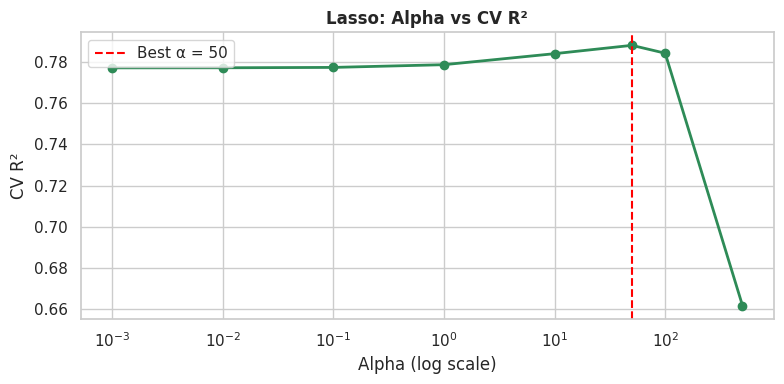


--- Tuning Ridge with GridSearchCV ---
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Alpha  : 10
CV R²       : 0.7795
Test R²     : 0.7614
RMSE        : 1,820.26
MAPE        : 21.12%


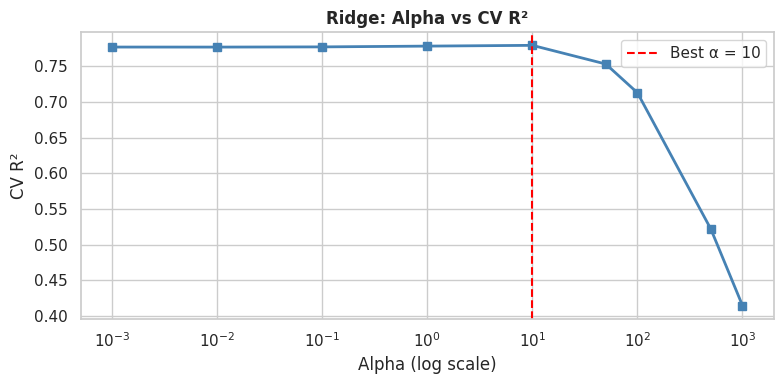


📊 Final Model Comparison:
            Model         MAE        RMSE  MAPE (%)       R²    CV R²
Linear Regression 1317.685573 1818.753051 21.130000 0.761815 0.790306
    Ridge (Tuned) 1319.810727 1820.261820 21.124964 0.761420 0.779545
    Lasso (Tuned) 1311.746662 1823.076550 20.866770 0.760681 0.787948


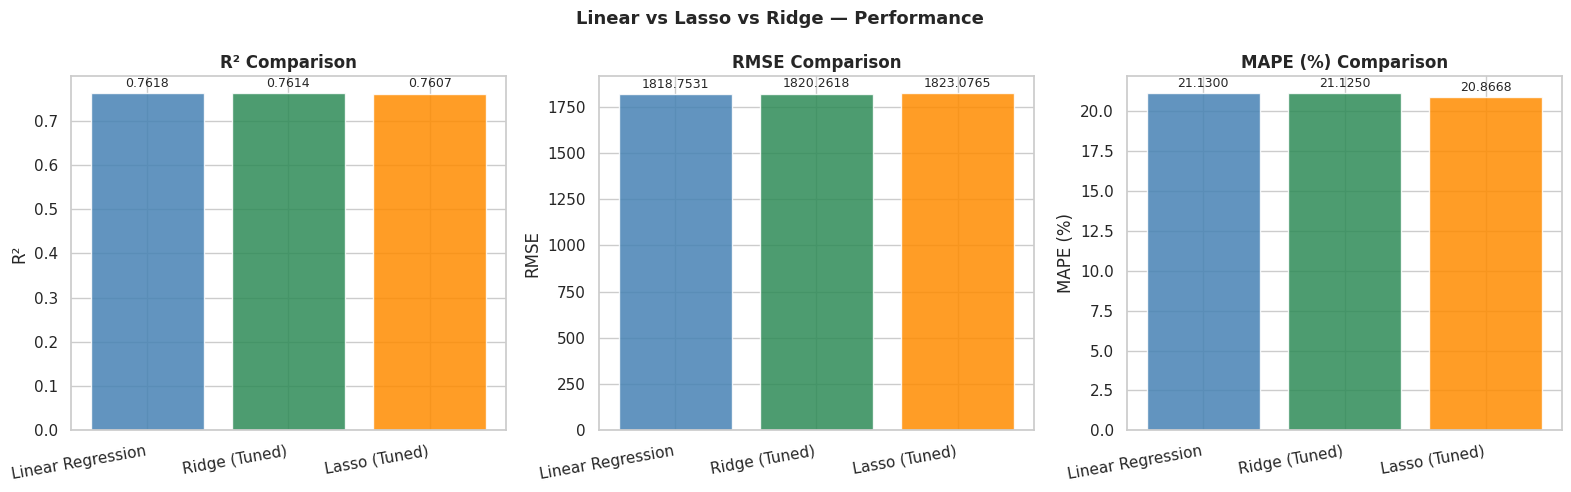

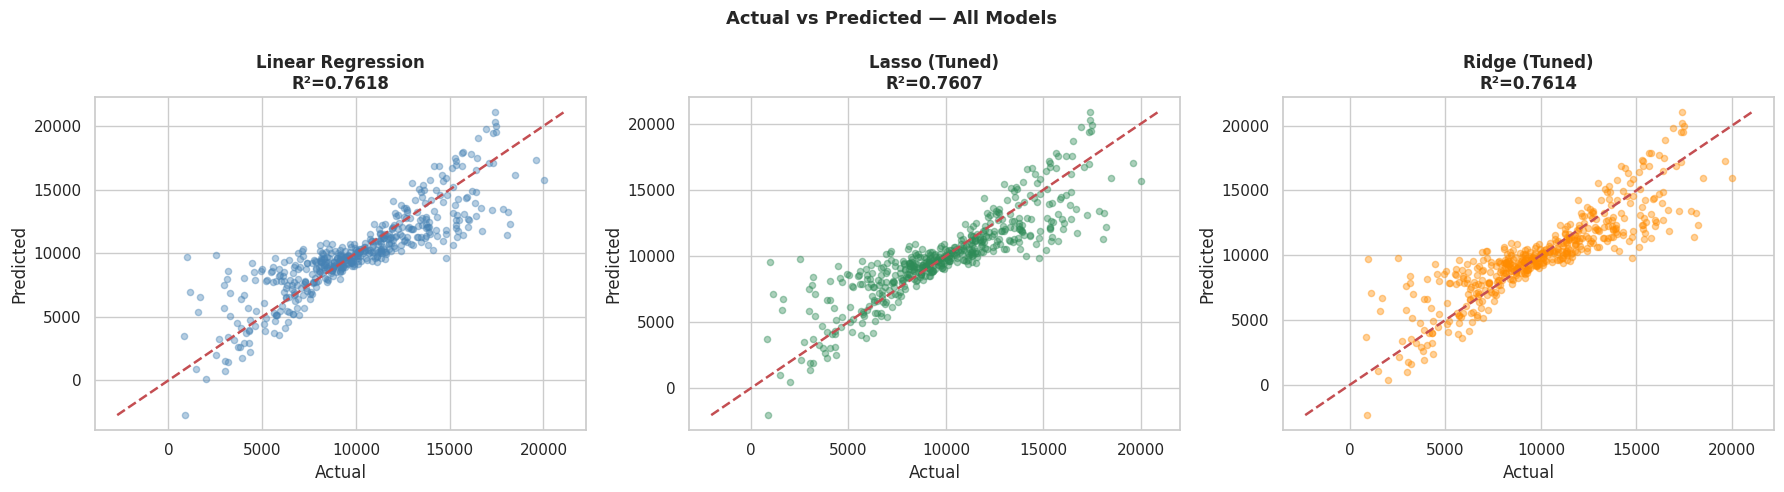

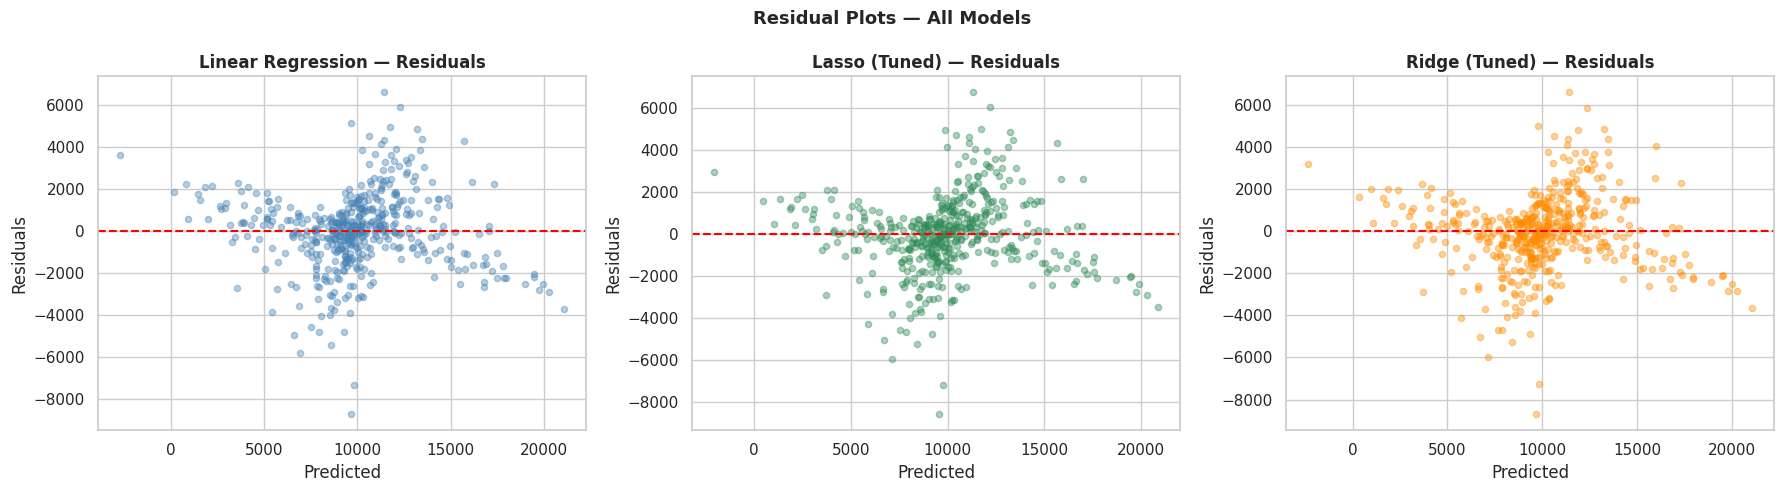

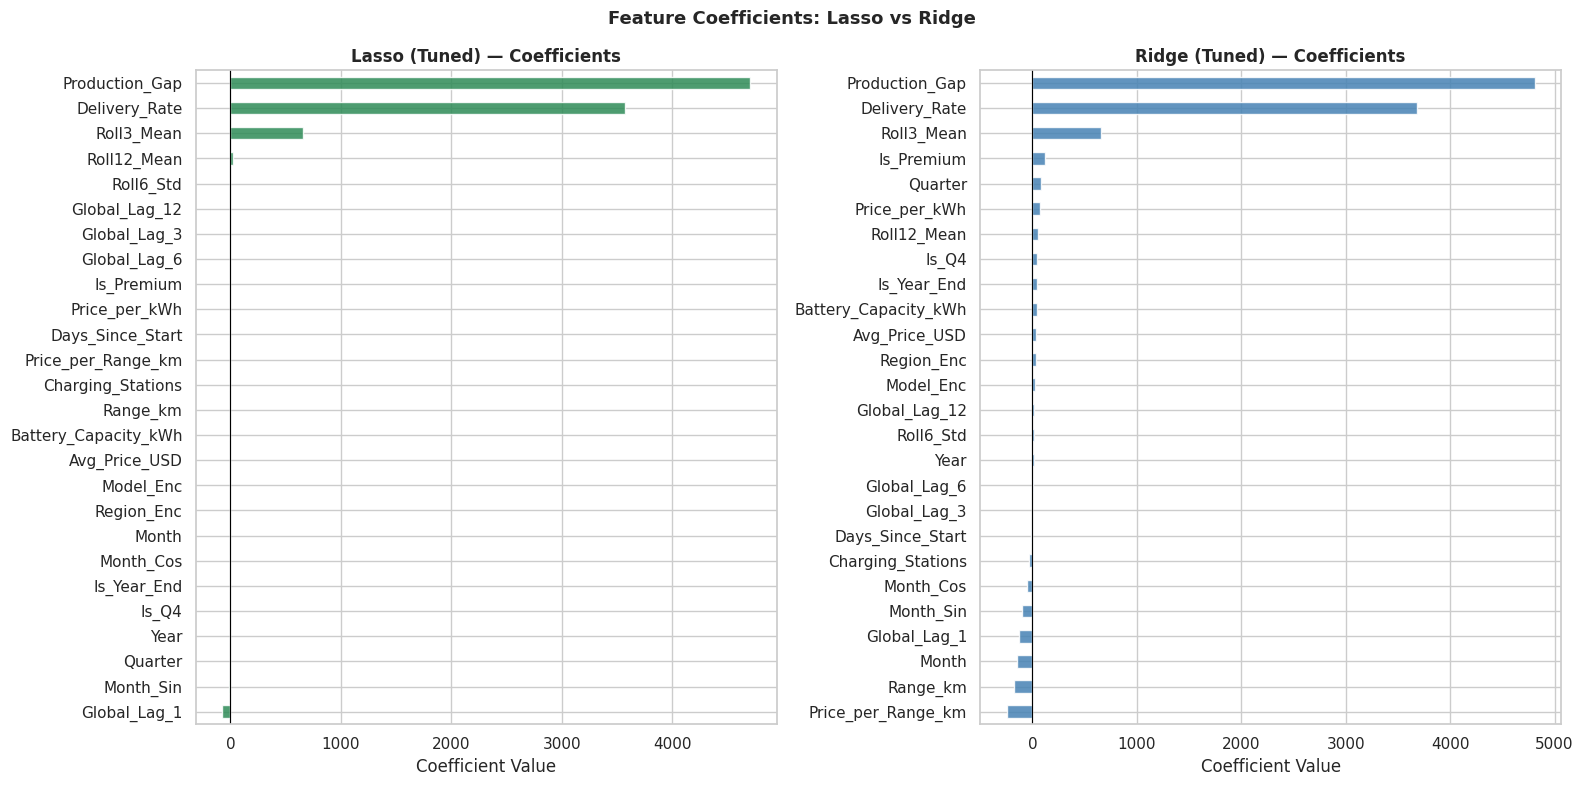


    REGRESSION SUMMARY
  Models trained     : 3
  Tuning method      : GridSearchCV
  CV strategy        : TimeSeriesSplit(5)
  Best Lasso α       : 50
  Best Ridge α       : 10
  Best Model         : Linear Regression
  Best R²            : 0.7618
  Best RMSE          : 1,818.75
  Best MAPE          : 21.13%


In [14]:
# ════════════════════════════════════════════════════════
#   CELL 5 : REGRESSION MODELING
#   Models  : Linear Regression | Lasso | Ridge
#   Tuning  : GridSearchCV (with TimeSeriesSplit)
# ════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import GridSearchCV, cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# ── Step 1: Train / Test Split ────────────────────────────
split_idx = int(len(df_fe) * 0.8)
X_train   = X.iloc[:split_idx]
X_test    = X.iloc[split_idx:]
y_train   = y.iloc[:split_idx]
y_test    = y.iloc[split_idx:]

# Scale features — mandatory for linear models
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size : {X_train.shape[0]:,} rows")
print(f"Test  size : {X_test.shape[0]:,} rows")
print(f"Features   : {X_train.shape[1]}")

# ── Step 2: Helper Function ───────────────────────────────
def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    pred  = model.predict(X_te)
    mae   = mean_absolute_error(y_te, pred)
    rmse  = np.sqrt(mean_squared_error(y_te, pred))
    mape  = mean_absolute_percentage_error(y_te, pred) * 100
    r2    = r2_score(y_te, pred)
    cv_r2 = cross_val_score(
                model, X_tr, y_tr,
                cv=5, scoring='r2').mean()
    return {"Model": name, "MAE": mae, "RMSE": rmse,
            "MAPE (%)": round(mape, 2),
            "R²": r2, "CV R²": cv_r2,
            "_pred": pred, "_model": model}

results = []

# ── Step 3: Linear Regression ─────────────────────────────
lr_result = evaluate(
    "Linear Regression",
    LinearRegression(),
    X_train_sc, X_test_sc, y_train, y_test)
results.append(lr_result)
print("\n✅ Linear Regression trained")
print(f"   R²      : {lr_result['R²']:.4f}")
print(f"   CV R²   : {lr_result['CV R²']:.4f}")
print(f"   RMSE    : {lr_result['RMSE']:,.2f}")
print(f"   MAPE    : {lr_result['MAPE (%)']:.2f}%")

# ── Step 4: Lasso — GridSearchCV ──────────────────────────
print("\n--- Tuning Lasso with GridSearchCV ---")
lasso_param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 50, 100, 500]
}
gs_lasso = GridSearchCV(
    Lasso(max_iter=10000), # Increased max_iter for higher alpha convergence stability
    lasso_param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="r2",
    n_jobs=-1,
    verbose=1
)
gs_lasso.fit(X_train_sc, y_train)

best_lasso   = gs_lasso.best_estimator_
lasso_pred   = best_lasso.predict(X_test_sc)
lasso_result = {
    "Model"    : "Lasso (Tuned)",
    "MAE"      : mean_absolute_error(y_test, lasso_pred),
    "RMSE"     : np.sqrt(mean_squared_error(y_test, lasso_pred)),
    "MAPE (%)" : mean_absolute_percentage_error(y_test, lasso_pred) * 100,
    "R²"       : r2_score(y_test, lasso_pred),
    "CV R²"    : gs_lasso.best_score_,
    "_pred"    : lasso_pred,
    "_model"   : best_lasso
}
results.append(lasso_result)

print(f"Best Alpha  : {gs_lasso.best_params_['alpha']}")
print(f"CV R²       : {gs_lasso.best_score_:.4f}")
print(f"Test R²     : {lasso_result['R²']:.4f}")
print(f"RMSE        : {lasso_result['RMSE']:,.2f}")
print(f"MAPE        : {lasso_result['MAPE (%)']:.2f}%")

# Lasso alpha sensitivity plot
lasso_cv_means = gs_lasso.cv_results_["mean_test_score"]
lasso_alphas   = lasso_param_grid["alpha"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lasso_alphas, lasso_cv_means, marker="o", color="seagreen", lw=2)
ax.axvline(gs_lasso.best_params_["alpha"], color="red", linestyle="--",
           label=f"Best α = {gs_lasso.best_params_['alpha']}")
ax.set_xscale("log")
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("CV R²")
ax.set_title("Lasso: Alpha vs CV R²", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# ── Step 5: Ridge — GridSearchCV ──────────────────────────
print("\n--- Tuning Ridge with GridSearchCV ---")
ridge_param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]
}
gs_ridge = GridSearchCV(
    Ridge(),
    ridge_param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="r2",
    n_jobs=-1,
    verbose=1
)
gs_ridge.fit(X_train_sc, y_train)

best_ridge   = gs_ridge.best_estimator_
ridge_pred   = best_ridge.predict(X_test_sc)
ridge_result = {
    "Model"    : "Ridge (Tuned)",
    "MAE"      : mean_absolute_error(y_test, ridge_pred),
    "RMSE"     : np.sqrt(mean_squared_error(y_test, ridge_pred)),
    "MAPE (%)" : mean_absolute_percentage_error(y_test, ridge_pred) * 100,
    "R²"       : r2_score(y_test, ridge_pred),
    "CV R²"    : gs_ridge.best_score_,
    "_pred"    : ridge_pred,
    "_model"   : best_ridge
}
results.append(ridge_result)

print(f"Best Alpha  : {gs_ridge.best_params_['alpha']}")
print(f"CV R²       : {gs_ridge.best_score_:.4f}")
print(f"Test R²     : {ridge_result['R²']:.4f}")
print(f"RMSE        : {ridge_result['RMSE']:,.2f}")
print(f"MAPE        : {ridge_result['MAPE (%)']:.2f}%")

# Ridge alpha sensitivity plot
ridge_cv_means = gs_ridge.cv_results_["mean_test_score"]
ridge_alphas   = ridge_param_grid["alpha"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ridge_alphas, ridge_cv_means, marker="s", color="steelblue", lw=2)
ax.axvline(gs_ridge.best_params_["alpha"], color="red", linestyle="--",
           label=f"Best α = {gs_ridge.best_params_['alpha']}")
ax.set_xscale("log")
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("CV R²")
ax.set_title("Ridge: Alpha vs CV R²", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# ── Step 6: Model Comparison Table ───────────────────────
metrics_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith("_")}
    for r in results
]).sort_values("R²", ascending=False).reset_index(drop=True)

print("\n📊 Final Model Comparison:")
print(metrics_df.to_string(index=False))

# ── Step 7: Comparison Bar Chart ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names = metrics_df["Model"]
colors      = ["steelblue", "seagreen", "darkorange"]

for ax, metric in zip(axes, ["R²", "RMSE", "MAPE (%)"]):
    vals = [metrics_df.loc[metrics_df["Model"]==m, metric].values[0] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors, edgecolor="white", alpha=0.85)
    ax.set_title(f"{metric} Comparison", fontweight="bold")
    ax.set_ylabel(metric)
    ax.set_xticks(range(len(model_names))) # Added explicit ticks to avoid warning
    ax.set_xticklabels(model_names, rotation=10, ha="right")
    
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f"{val:.4f}" if "R" in metric or "MAPE" in metric else f"{val:,.0f}",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("Linear vs Lasso vs Ridge — Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Step 8: Actual vs Predicted — All 3 Models ────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_data = [
    ("Linear Regression", lr_result["_pred"],    "steelblue"),
    ("Lasso (Tuned)",     lasso_result["_pred"],  "seagreen"),
    ("Ridge (Tuned)",     ridge_result["_pred"],  "darkorange"),
]
for ax, (name, pred, color) in zip(axes, plot_data):
    ax.scatter(y_test, pred, alpha=0.4, s=20, color=color)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, "r--", lw=1.8)
    r2 = r2_score(y_test, pred)
    ax.set_title(f"{name}\nR²={r2:.4f}", fontweight="bold")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

plt.suptitle("Actual vs Predicted — All Models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Step 9: Residuals — All 3 Models ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, pred, color) in zip(axes, plot_data):
    residuals = y_test.values - pred
    ax.scatter(pred, residuals, alpha=0.4, s=20, color=color)
    ax.axhline(0, color="red", lw=1.5, linestyle="--")
    ax.set_title(f"{name} — Residuals", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residuals")

plt.suptitle("Residual Plots — All Models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Step 10: Coefficient Analysis ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, (name, model, color) in zip(axes, [
    ("Lasso (Tuned)", best_lasso, "seagreen"),
    ("Ridge (Tuned)", best_ridge, "steelblue"),
]):
    coef = pd.Series(model.coef_, index=model_features).sort_values()
    coef.plot(kind="barh", ax=ax, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(f"{name} — Coefficients", fontweight="bold")
    ax.set_xlabel("Coefficient Value")

plt.suptitle("Feature Coefficients: Lasso vs Ridge", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Final Summary ─────────────────────────────────────────
best_row = metrics_df.iloc[0]
print("\n" + "="*45)
print("    REGRESSION SUMMARY")
print("="*45)
print(f"  Models trained     : 3")
print(f"  Tuning method      : GridSearchCV")
print(f"  CV strategy        : TimeSeriesSplit(5)")
print(f"  Best Lasso α       : {gs_lasso.best_params_['alpha']}")
print(f"  Best Ridge α       : {gs_ridge.best_params_['alpha']}")
print(f"  Best Model         : {best_row['Model']}")
print(f"  Best R²            : {best_row['R²']:.4f}")
print(f"  Best RMSE          : {best_row['RMSE']:,.2f}")
print(f"  Best MAPE          : {best_row['MAPE (%)']:.2f}%")
print("="*45)

# Cell 6: Time Series Forecasting (SARIMA)
**Action: Aggregating data globally to forecast overall future deliveries using seasonal ARIMA.**

--- Sales Time Series Decomposition ---


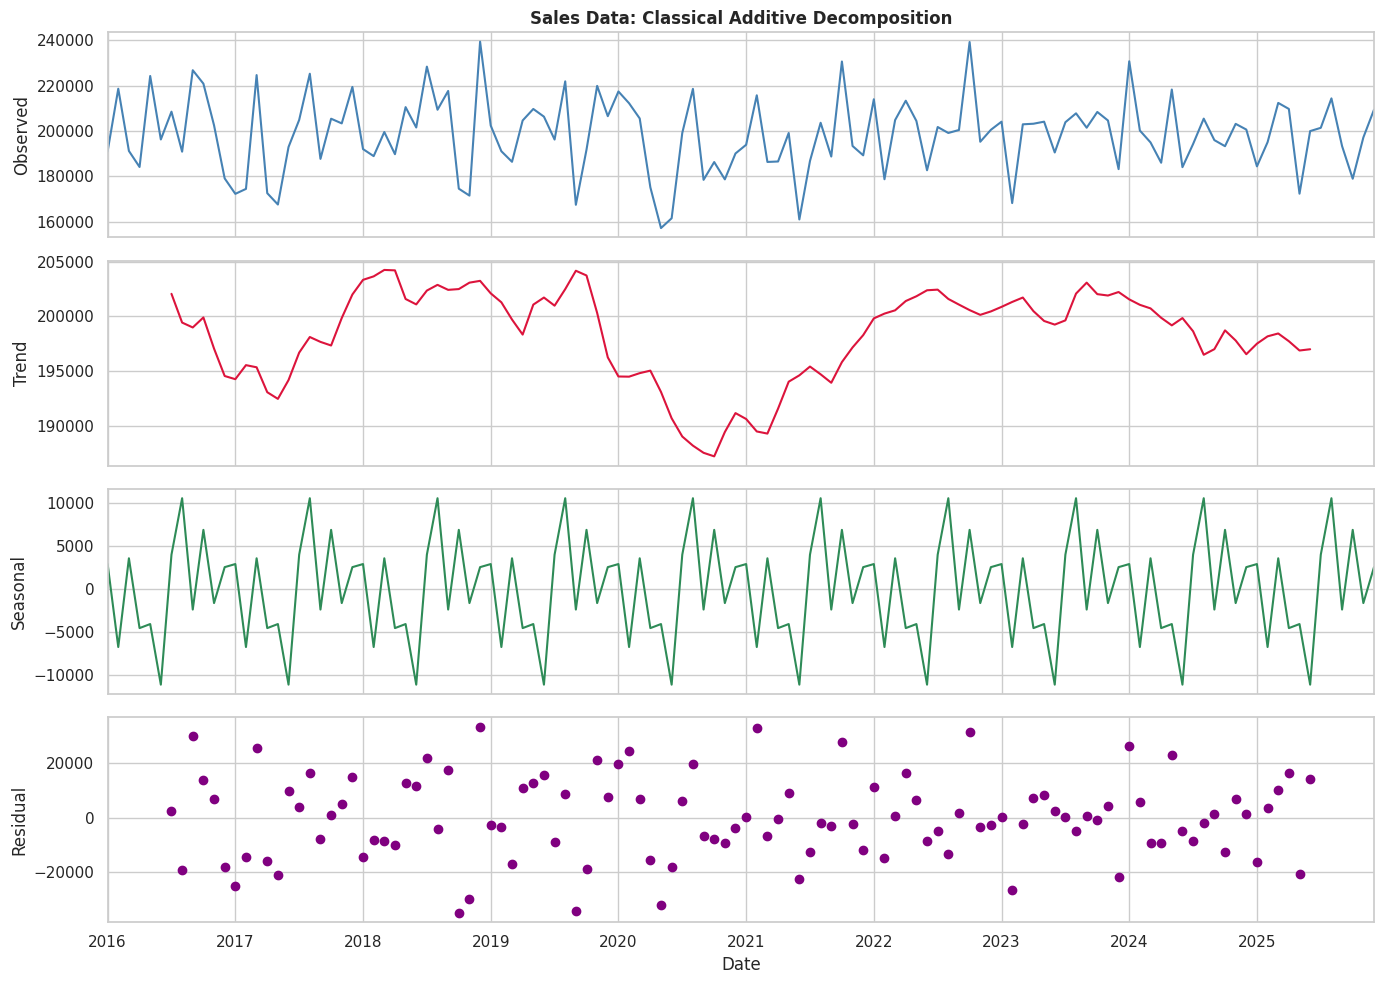


--- Sales Forecast Validation Strategy (TimeSeriesSplit) ---
  Fold 1 - Validation Window MAPE: 40.46%
  Fold 2 - Validation Window MAPE: 10.67%
  Fold 3 - Validation Window MAPE: 6.94%
  Mean Cross-Validated Forecast MAPE: 19.35%

Training TS window points: 96 months
Testing TS window points : 24 months

  SARIMA TEST METRICS (SALES)
  MAE    :    13,418.63
  RMSE   :    16,619.00
  MAPE   :        6.79%
  R²     :      -0.6873


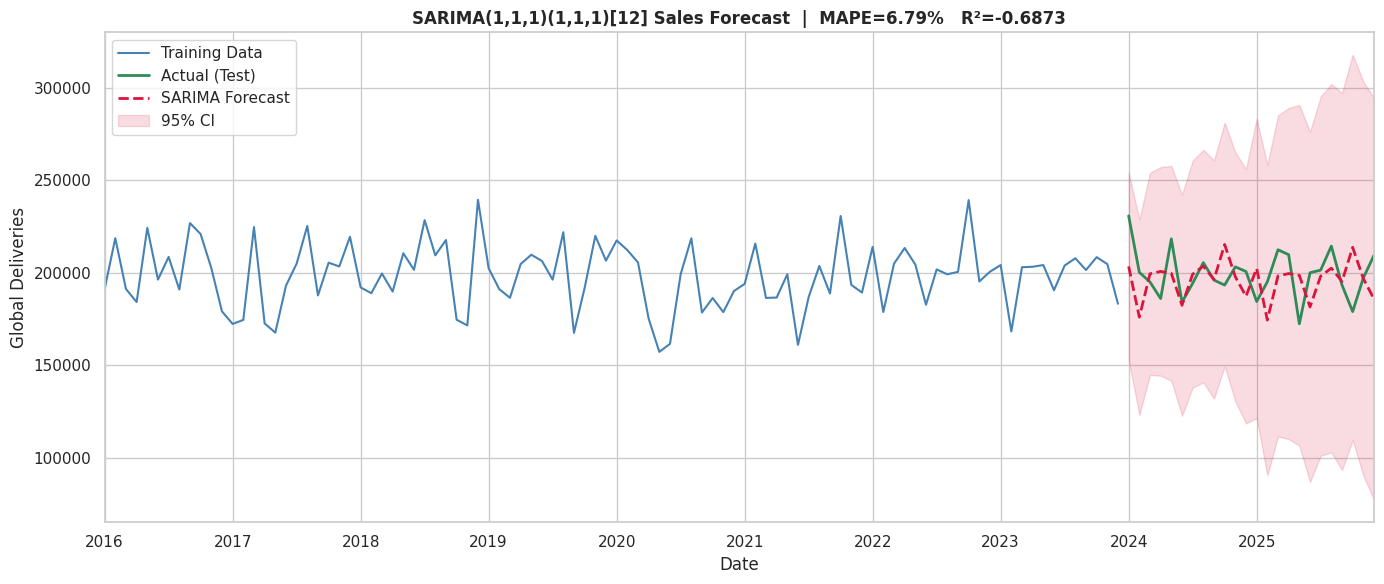

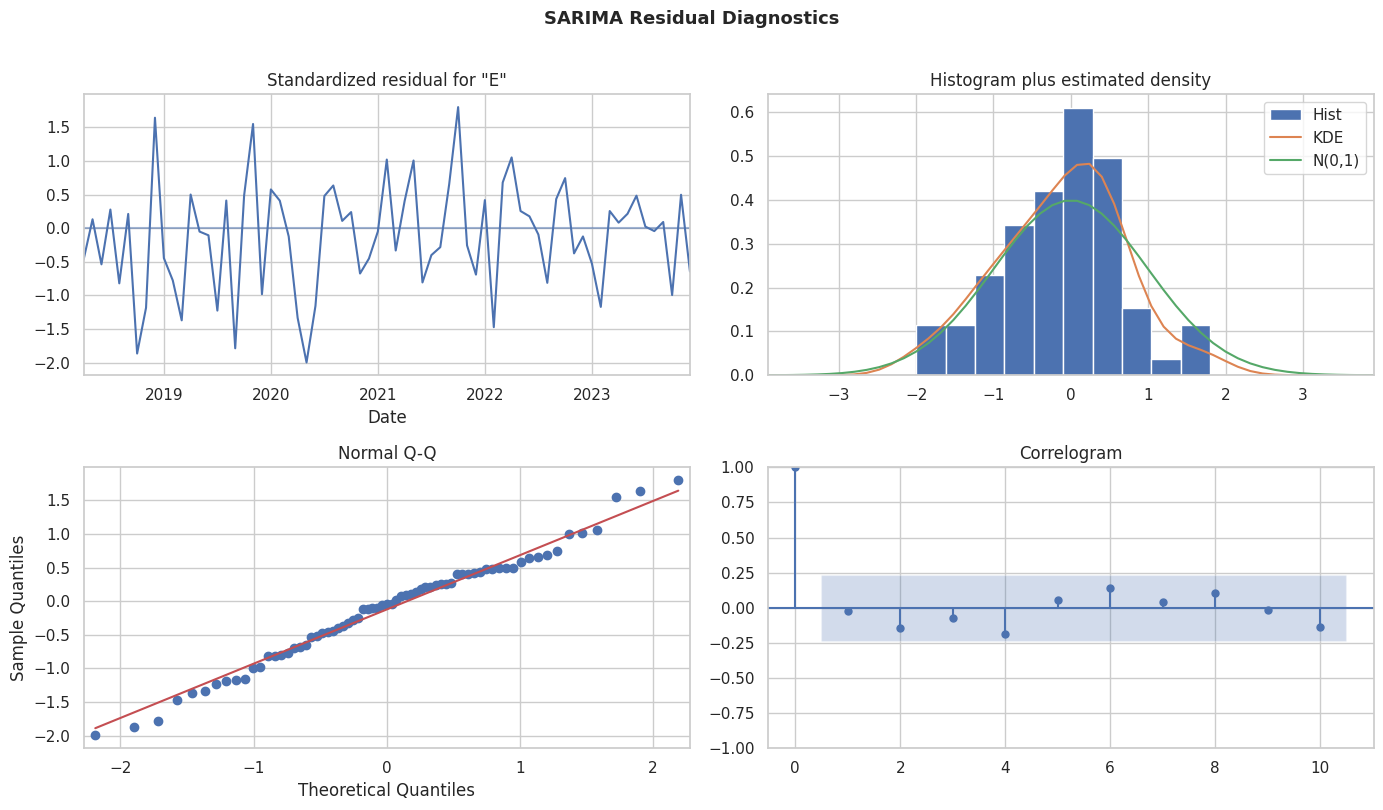


  PRICE FORECASTING ANALYSIS
  Price MAE  : $  3,817.37
  Price RMSE : $  4,824.88
  Price MAPE :       4.45%
  Price R²   :    -0.4219


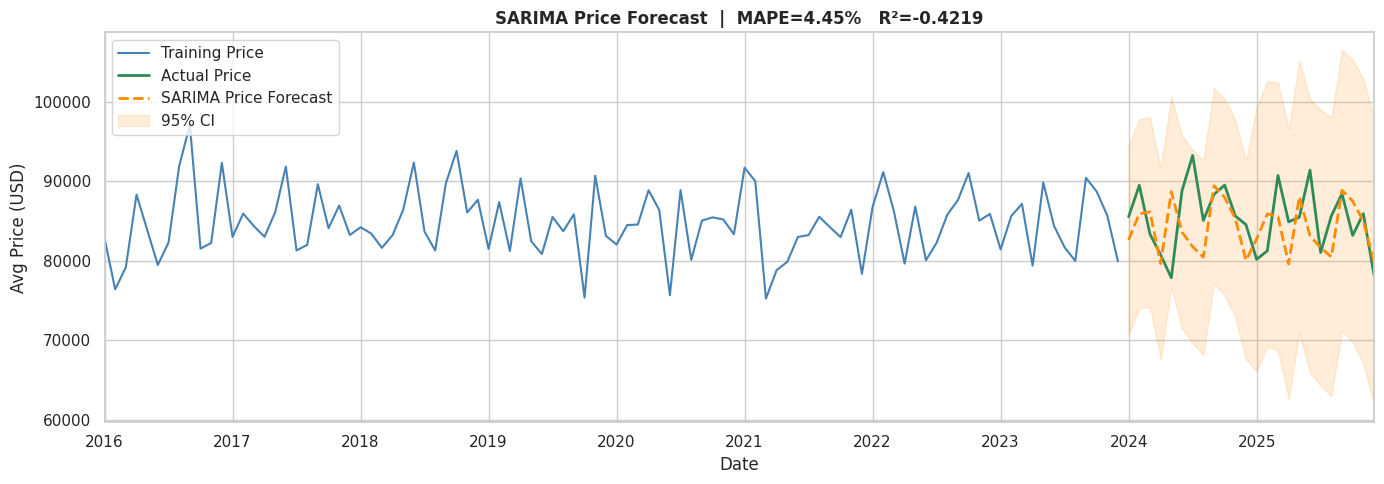

In [15]:
# ════════════════════════════════════════════════════════
#   CELL 6: TIME SERIES FORECASTING (SALES & PRICE)
#   Methods  : Seasonal Decompose | TimeSeriesSplit | SARIMAX
# ════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit

# ── Step 1: Time Series Aggregation & Frequency Setting ─────
# Ensure index is correctly prepared as a chronological regular PeriodIndex
ts_sales = df_fe.groupby('Date')['Estimated_Deliveries'].sum()
ts_price = df_fe.groupby('Date')['Avg_Price_USD'].mean()

ts_sales.index = pd.DatetimeIndex(ts_sales.index).to_period('M')
ts_price.index = pd.DatetimeIndex(ts_price.index).to_period('M')

# Calculate test steps dynamically (20% of timeline data)
n_test = int(len(ts_sales) * 0.2)

# ── Step 2: Time Series Decomposition ───────────────────────
print("--- Sales Time Series Decomposition ---")
# Convert to timestamp for seasonal_decompose compatibility
decomp_sales = seasonal_decompose(ts_sales.to_timestamp(), model='additive')

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp_sales.observed.plot(ax=axes[0], color='steelblue', legend=False)
axes[0].set_ylabel('Observed')
axes[0].set_title('Sales Data: Classical Additive Decomposition', fontweight='bold')

decomp_sales.trend.plot(ax=axes[1], color='crimson', legend=False)
axes[1].set_ylabel('Trend')

decomp_sales.seasonal.plot(ax=axes[2], color='seagreen', legend=False)
axes[2].set_ylabel('Seasonal')

decomp_sales.resid.plot(ax=axes[3], color='purple', style='o', legend=False)
axes[3].set_ylabel('Residual')
plt.tight_layout()
plt.show()

# ── Step 3: Sales Cross-Validation (TimeSeriesSplit) ────────
print("\n--- Sales Forecast Validation Strategy (TimeSeriesSplit) ---")
tscv = TimeSeriesSplit(n_splits=3)
cv_scores = []

# Validate across sliding windows
for fold, (train_idx, val_idx) in enumerate(tscv.split(ts_sales), 1):
    cv_train = ts_sales.iloc[train_idx]
    cv_val = ts_sales.iloc[val_idx]
    
    try:
        cv_model = SARIMAX(cv_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                           enforce_stationarity=False, enforce_invertibility=False)
        cv_fit = cv_model.fit(disp=False)
        cv_fc = cv_fit.get_forecast(steps=len(cv_val)).predicted_mean
        cv_mape = mean_absolute_percentage_error(cv_val, cv_fc) * 100
        cv_scores.append(cv_mape)
        print(f"  Fold {fold} - Validation Window MAPE: {cv_mape:.2f}%")
    except:
        continue

print(f"  Mean Cross-Validated Forecast MAPE: {np.mean(cv_scores):.2f}%")

# ── Step 4: Final Split & Model Instantiation ───────────────
train_ts = ts_sales.iloc[:-n_test]
test_ts  = ts_sales.iloc[-n_test:]

print(f"\nTraining TS window points: {len(train_ts)} months")
print(f"Testing TS window points : {len(test_ts)} months")

sarima_model = SARIMAX(train_ts,
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_results = sarima_model.fit(disp=False)

# ── Step 5: Sales Forecasting Extraction ────────────────────
forecast      = sarima_results.get_forecast(steps=n_test)
forecast_mean = forecast.predicted_mean
conf_int      = forecast.conf_int()

# Align frequency parameters for accurate comparison plots
forecast_mean.index = test_ts.index

# ── Step 6: SARIMA Evaluation — All Metrics ───────────────
ts_mae  = mean_absolute_error(test_ts, forecast_mean)
ts_rmse = np.sqrt(mean_squared_error(test_ts, forecast_mean))
ts_mape = mean_absolute_percentage_error(test_ts, forecast_mean) * 100
ts_r2   = r2_score(test_ts, forecast_mean)

print("\n" + "="*40)
print("  SARIMA TEST METRICS (SALES)")
print("="*40)
print(f"  MAE    : {ts_mae:>12,.2f}")
print(f"  RMSE   : {ts_rmse:>12,.2f}")
print(f"  MAPE   : {ts_mape:>11.2f}%")
print(f"  R²     : {ts_r2:>12.4f}")
print("="*40)

# ── Step 7: Forecast Plot ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
train_ts.plot(ax=ax, color='steelblue', lw=1.5, label='Training Data')
test_ts.plot(ax=ax, color='seagreen', lw=2, label='Actual (Test)')
forecast_mean.plot(ax=ax, color='crimson', lw=2, linestyle='--', label='SARIMA Forecast')

ax.fill_between(conf_int.index.to_timestamp(),
                conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                color='crimson', alpha=0.15, label='95% CI')
ax.set_title(f'SARIMA(1,1,1)(1,1,1)[12] Sales Forecast  |  MAPE={ts_mape:.2f}%   R²={ts_r2:.4f}', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Global Deliveries')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# ── Step 8: Residual Diagnostics ─────────────────────────
sarima_results.plot_diagnostics(figsize=(14, 8))
plt.suptitle('SARIMA Residual Diagnostics', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Step 9: Price Forecasting with SARIMA ────────────────
print("\n" + "="*40)
print("  PRICE FORECASTING ANALYSIS")
print("="*40)
train_price = ts_price.iloc[:-n_test]
test_price  = ts_price.iloc[-n_test:]

price_model = SARIMAX(train_price,
                      order=(1, 1, 1),
                      seasonal_order=(1, 1, 1, 12),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
price_fit     = price_model.fit(disp=False)
price_fc      = price_fit.get_forecast(steps=n_test)
price_mean    = price_fc.predicted_mean
price_conf    = price_fc.conf_int()

# Align frequency parameters
price_mean.index = test_price.index

price_mae  = mean_absolute_error(test_price, price_mean)
price_rmse = np.sqrt(mean_squared_error(test_price, price_mean))
price_mape = mean_absolute_percentage_error(test_price, price_mean) * 100
price_r2   = r2_score(test_price, price_mean)

print(f"  Price MAE  : ${price_mae:>10,.2f}")
print(f"  Price RMSE : ${price_rmse:>10,.2f}")
print(f"  Price MAPE : {price_mape:>10.2f}%")
print(f"  Price R²   : {price_r2:>10.4f}")
print("="*40)

# ── Step 10: Price Forecast Plot ──────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
train_price.plot(ax=ax, color='steelblue', lw=1.5, label='Training Price')
test_price.plot(ax=ax, color='seagreen', lw=2, label='Actual Price')
price_mean.plot(ax=ax, color='darkorange', lw=2, linestyle='--', label='SARIMA Price Forecast')

ax.fill_between(price_conf.index.to_timestamp(),
                price_conf.iloc[:, 0], price_conf.iloc[:, 1],
                color='darkorange', alpha=0.15, label='95% CI')
ax.set_title(f'SARIMA Price Forecast  |  MAPE={price_mape:.2f}%   R²={price_r2:.4f}', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Price (USD)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()